# Fund Performance Analytics
**Bluestock MF Project — Listed India (Bluestock Fintech)**
Prepared by: Riyaz | Data Analyst Intern

This notebook computes, for all 40 mutual fund schemes in `01_fund_master.csv` / `02_nav_history.csv`:
daily returns, CAGR (1Y/3Y/5Y), Sharpe & Sortino ratios, Alpha/Beta (OLS vs benchmark), Maximum Drawdown,
a composite 0–100 Fund Scorecard, and a benchmark comparison chart with tracking error.

**Data window available:** 2022-01-03 to 2026-05-29 (~4.40 years, 1,150 trading days/scheme).

## 1. Load Data & Validate

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

nav = pd.read_csv('02_nav_history.csv')
fund_master = pd.read_csv('01_fund_master.csv')
benchmark = pd.read_csv('10_benchmark_indices.csv')

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

print("NAV history:", nav.shape, "| schemes:", nav.amfi_code.nunique(),
      "| date range:", nav.date.min().date(), "to", nav.date.max().date())
print("Fund master:", fund_master.shape)
print("Benchmark indices:", benchmark.shape, "| indices:", list(benchmark.index_name.unique()))

NAV history: (46000, 3) | schemes: 40 | date range: 2022-01-03 to 2026-05-29
Fund master: (40, 15)
Benchmark indices: (8050, 3) | indices: ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']


In [2]:
print("--- Validation ---")
print("Null values - nav:", nav.isnull().sum().sum(), "| fund_master:", fund_master.isnull().sum().sum(),
      "| benchmark:", benchmark.isnull().sum().sum())
print("Duplicate (amfi_code,date) rows in nav:", nav.duplicated(subset=['amfi_code','date']).sum())
print("Duplicate (index_name,date) rows in benchmark:", benchmark.duplicated(subset=['index_name','date']).sum())

rows_per_scheme = nav.groupby('amfi_code').size()
print("Rows per scheme -> min:", rows_per_scheme.min(), "max:", rows_per_scheme.max(),
      "| unique fund count:", rows_per_scheme.shape[0])
assert set(fund_master.amfi_code) == set(nav.amfi_code), "Mismatch between fund_master and nav schemes"

neg_nav = (nav['nav'] <= 0).sum()
print("Non-positive NAV rows:", neg_nav)
print("\\nAll checks passed: no nulls, no duplicates, all 40 schemes present, all NAVs positive.")

--- Validation ---
Null values - nav: 0 | fund_master: 0 | benchmark: 0
Duplicate (amfi_code,date) rows in nav: 0
Duplicate (index_name,date) rows in benchmark: 0
Rows per scheme -> min: 1150 max: 1150 | unique fund count: 40
Non-positive NAV rows: 0
\nAll checks passed: no nulls, no duplicates, all 40 schemes present, all NAVs positive.


### Benchmark name mapping
`01_fund_master.csv` lists each fund's official benchmark using descriptive TRI names
(e.g. `NIFTY 100 TRI`), while `10_benchmark_indices.csv` only contains **7** short-coded
index series. 7 of the 10 distinct benchmark names map exactly. The remaining 3
(`CRISIL Short Term Bond Index`, `NIFTY Midcap 50 TRI`, `NIFTY Large Midcap 250 TRI`)
have **no exact series provided** — the closest available index is used as a documented
proxy (flagged below). This affects only Alpha/Beta and Tracking Error for the funds
using those 3 benchmarks (6 of 40 funds).

In [3]:
BENCHMARK_MAP = {
    'NIFTY 100 TRI':                'NIFTY100',
    'NIFTY 50 TRI':                  'NIFTY50',
    'NIFTY 500 TRI':                 'NIFTY500',
    'NIFTY Midcap 150 TRI':          'NIFTY_MIDCAP150',
    'BSE 250 SmallCap TRI':          'BSE_SMALLCAP',
    'CRISIL Liquid Fund AI Index':   'CRISIL_LIQUID',
    'CRISIL Dynamic Gilt Index':     'CRISIL_GILT',
    # --- No exact match in 10_benchmark_indices.csv -> nearest-available proxy (documented assumption) ---
    'CRISIL Short Term Bond Index':  'CRISIL_LIQUID',       # proxy: closest available short-duration debt index
    'NIFTY Midcap 50 TRI':           'NIFTY_MIDCAP150',     # proxy: closest available midcap index
    'NIFTY Large Midcap 250 TRI':    'NIFTY500',            # proxy: closest broad large+midcap blend available
}
fund_master['benchmark_code'] = fund_master['benchmark'].map(BENCHMARK_MAP)
print("Unmapped benchmarks (should be none):", fund_master[fund_master.benchmark_code.isnull()].benchmark.unique())
print()
print(fund_master[['benchmark','benchmark_code']].drop_duplicates().to_string(index=False))

Unmapped benchmarks (should be none): <StringArray>
[]
Length: 0, dtype: str

                   benchmark  benchmark_code
               NIFTY 100 TRI        NIFTY100
        BSE 250 SmallCap TRI    BSE_SMALLCAP
   CRISIL Dynamic Gilt Index     CRISIL_GILT
        NIFTY Midcap 150 TRI NIFTY_MIDCAP150
CRISIL Short Term Bond Index   CRISIL_LIQUID
               NIFTY 500 TRI        NIFTY500
 CRISIL Liquid Fund AI Index   CRISIL_LIQUID
                NIFTY 50 TRI         NIFTY50
         NIFTY Midcap 50 TRI NIFTY_MIDCAP150
  NIFTY Large Midcap 250 TRI        NIFTY500


## 2. Daily Returns

In [4]:
nav_wide = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()
print("NAV wide matrix shape:", nav_wide.shape)

daily_returns = nav_wide.pct_change().dropna(how='all')
print("Daily returns matrix shape:", daily_returns.shape)

NAV wide matrix shape: (1150, 40)
Daily returns matrix shape: (1149, 40)


In [5]:
# Distribution sanity check across all funds, all days
stats = daily_returns.stack().describe(percentiles=[.01,.05,.5,.95,.99])
print("Pooled daily-return distribution (all funds, all days):")
print(stats)

extreme = (daily_returns.abs() > 0.15).sum().sum()
print(f"\\nDaily |return| > 15% occurrences (should be rare/zero for MFs): {extreme}")
print("Distribution looks reasonable: mean ~0.06%/day, std ~1.0%/day, no NaNs, no extreme outliers.")

Pooled daily-return distribution (all funds, all days):
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
1%          -0.025982
5%          -0.016254
50%          0.000340
95%          0.017842
99%          0.027617
max          0.064713
dtype: float64
\nDaily |return| > 15% occurrences (should be rare/zero for MFs): 0
Distribution looks reasonable: mean ~0.06%/day, std ~1.0%/day, no NaNs, no extreme outliers.


## 3. CAGR — 1Y, 3Y, 5Y
`CAGR = (NAV_end / NAV_start) ^ (1/n) − 1`, where `n` is the actual elapsed years between the
two NAV dates. **Note:** the dataset spans only 4.40 years, so **5Y CAGR cannot be computed**
for any fund (insufficient history) and is reported as blank/NaN by design — not a data error.

In [6]:
end_date = nav_wide.index.max()

def cagr_for_horizon(years):
    target_start = end_date - pd.DateOffset(years=years)
    if target_start < nav_wide.index.min():
        return pd.Series(index=nav_wide.columns, dtype=float)
    start_date = nav_wide.index[nav_wide.index >= target_start][0]
    nav_start = nav_wide.loc[start_date]
    nav_end = nav_wide.loc[end_date]
    actual_years = (end_date - start_date).days / 365.25
    return (nav_end / nav_start) ** (1 / actual_years) - 1

cagr_1y = cagr_for_horizon(1)
cagr_3y = cagr_for_horizon(3)
cagr_5y = cagr_for_horizon(5)

print(f"Data span: {(end_date - nav_wide.index.min()).days/365.25:.2f} years "
      f"({nav_wide.index.min().date()} to {end_date.date()})")
print("5Y CAGR computable for any fund?", bool(cagr_5y.notna().any()))

cagr_table = pd.DataFrame({'CAGR_1Y': cagr_1y, 'CAGR_3Y': cagr_3y, 'CAGR_5Y': cagr_5y})
cagr_table.index.name = 'amfi_code'
cagr_table = cagr_table.merge(fund_master[['amfi_code','scheme_name','category']],
                               on='amfi_code').set_index('amfi_code')
cagr_table = cagr_table[['scheme_name','category','CAGR_1Y','CAGR_3Y','CAGR_5Y']]

print("\\nCAGR comparison — Top 10 funds by 3Y CAGR:")
print(cagr_table.sort_values('CAGR_3Y', ascending=False).head(10).round(4).to_string())

Data span: 4.40 years (2022-01-03 to 2026-05-29)
5Y CAGR computable for any fund? False
\nCAGR comparison — Top 10 funds by 3Y CAGR:
                                                  scheme_name category  CAGR_1Y  CAGR_3Y  CAGR_5Y
amfi_code                                                                                        
119094                    Axis Midcap Fund - Regular - Growth   Equity   0.2228   0.3510      NaN
148567          Mirae Asset Large Cap Fund - Regular - Growth   Equity   0.2038   0.3399      NaN
120504              ICICI Pru Bluechip Fund - Direct - Growth   Equity   0.1307   0.3248      NaN
100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity   0.5328   0.3243      NaN
120505               ICICI Pru Midcap Fund - Regular - Growth   Equity   0.2963   0.3177      NaN
119551              SBI Bluechip Fund - Regular Plan - Growth   Equity   0.6049   0.3045      NaN
120843                 Kotak Flexicap Fund - Regular - Growth   Equity   0.2668   0

## 4. Sharpe Ratio
`Sharpe = (Rp − Rf) / Std(Rp) × √252`, using **Rf = 6.5% annual** (RBI repo rate proxy),
converted to a daily rate by simple division. Ranked across all 40 funds.

In [7]:
RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252

sharpe, sortino = {}, {}
for c in daily_returns.columns:
    r = daily_returns[c].dropna()
    excess = r - RF_DAILY
    std = r.std()
    sharpe[c] = (excess.mean() / std) * np.sqrt(TRADING_DAYS) if std > 0 else np.nan

    downside = r[r < 0]
    dstd = downside.std()
    sortino[c] = (excess.mean() / dstd) * np.sqrt(TRADING_DAYS) if dstd and dstd > 0 else np.nan

ratios = pd.concat([pd.Series(sharpe, name='Sharpe_Ratio'), pd.Series(sortino, name='Sortino_Ratio')], axis=1)
ratios.index.name = 'amfi_code'
ratios = ratios.merge(fund_master[['amfi_code','scheme_name','category']],
                       left_index=True, right_on='amfi_code').set_index('amfi_code')
ratios['Sharpe_Rank'] = ratios['Sharpe_Ratio'].rank(ascending=False, method='min').astype(int)
ratios = ratios.sort_values('Sharpe_Rank')

print(f"Risk-free rate: {RF_ANNUAL:.1%} annual -> {RF_DAILY:.6f} daily")
print("\\nSharpe Ratio ranking — Top 10:")
print(ratios[['scheme_name','category','Sharpe_Ratio','Sortino_Ratio','Sharpe_Rank']].head(10).round(4).to_string())
print("\\nBottom 5:")
print(ratios[['scheme_name','category','Sharpe_Ratio','Sortino_Ratio','Sharpe_Rank']].tail(5).round(4).to_string())

Risk-free rate: 6.5% annual -> 0.000258 daily
\nSharpe Ratio ranking — Top 10:
                                                  scheme_name category  Sharpe_Ratio  Sortino_Ratio  Sharpe_Rank
amfi_code                                                                                                       
148567          Mirae Asset Large Cap Fund - Regular - Growth   Equity        1.4483         2.3856            1
120843                 Kotak Flexicap Fund - Regular - Growth   Equity        1.3067         2.3643            2
148569          Mirae Asset Tax Saver Fund - Regular - Growth   Equity        1.2349         2.1469            3
119551              SBI Bluechip Fund - Regular Plan - Growth   Equity        1.2083         2.1403            4
120505               ICICI Pru Midcap Fund - Regular - Growth   Equity        1.1801         2.0294            5
149323                     DSP Midcap Fund - Regular - Growth   Equity        1.1321         1.8751            6
100033     HDFC M

## 5. Sortino Ratio
Same numerator as Sharpe; denominator uses **downside deviation only** (std of negative-return days). Computed together with Sharpe above (see `Sortino_Ratio` column).

In [8]:
print("Sharpe vs Sortino — full 40-fund ranking:")
print(ratios[['scheme_name','Sharpe_Ratio','Sortino_Ratio','Sharpe_Rank']].round(4).to_string())

Sharpe vs Sortino — full 40-fund ranking:
                                                     scheme_name  Sharpe_Ratio  Sortino_Ratio  Sharpe_Rank
amfi_code                                                                                                 
148567             Mirae Asset Large Cap Fund - Regular - Growth        1.4483         2.3856            1
120843                    Kotak Flexicap Fund - Regular - Growth        1.3067         2.3643            2
148569             Mirae Asset Tax Saver Fund - Regular - Growth        1.2349         2.1469            3
119551                 SBI Bluechip Fund - Regular Plan - Growth        1.2083         2.1403            4
120505                  ICICI Pru Midcap Fund - Regular - Growth        1.1801         2.0294            5
149323                        DSP Midcap Fund - Regular - Growth        1.1321         1.8751            6
100033        HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937         1.8291         

## 6. Alpha & Beta (OLS Regression)
For each fund, `scipy.stats.linregress(benchmark_daily_return, fund_daily_return)` against its
**own assigned benchmark** (see mapping above). `Alpha = intercept × 252` (annualized), `Beta = slope`.

In [9]:
from scipy.stats import linregress

bm_wide = benchmark.pivot(index='date', columns='index_name', values='close_value').sort_index()
bm_returns = bm_wide.pct_change().dropna(how='all')

rows = []
for code_ in daily_returns.columns:
    bench_code = fund_master.loc[fund_master.amfi_code == code_, 'benchmark_code'].values[0]
    bench_name = fund_master.loc[fund_master.amfi_code == code_, 'benchmark'].values[0]
    aligned = pd.concat([daily_returns[code_], bm_returns[bench_code]], axis=1,
                         keys=['fund','bench']).dropna()
    slope, intercept, r_value, p_value, std_err = linregress(aligned['bench'], aligned['fund'])
    rows.append({'amfi_code': code_,
                 'scheme_name': fund_master.loc[fund_master.amfi_code == code_, 'scheme_name'].values[0],
                 'benchmark': bench_name, 'benchmark_series_used': bench_code,
                 'Alpha_annualized': intercept * TRADING_DAYS, 'Beta': slope,
                 'R_squared': r_value**2, 'p_value': p_value, 'n_obs': len(aligned)})

alpha_beta = pd.DataFrame(rows).set_index('amfi_code')
alpha_beta['Alpha_Rank'] = alpha_beta['Alpha_annualized'].rank(ascending=False, method='min').astype(int)
alpha_beta = alpha_beta.sort_values('Alpha_Rank')

print("Alpha/Beta — Top 10 by annualized Alpha:")
print(alpha_beta[['scheme_name','benchmark','Alpha_annualized','Beta','R_squared','Alpha_Rank']]
      .head(10).round(4).to_string())
print("\\nNote: R-squared values are low across the book, meaning daily fund NAV moves in this")
print("dataset track their nominal benchmark only loosely day-to-day (typical of simulated NAV series).")

alpha_beta.round(4).to_csv('alpha_beta.csv')
print("\\nSaved: alpha_beta.csv")

Alpha/Beta — Top 10 by annualized Alpha:
                                                  scheme_name             benchmark  Alpha_annualized    Beta  R_squared  Alpha_Rank
amfi_code                                                                                                                           
119598             SBI Small Cap Fund - Regular Plan - Growth  BSE 250 SmallCap TRI            0.3151 -0.0476     0.0018           1
149324                  DSP Small Cap Fund - Regular - Growth  BSE 250 SmallCap TRI            0.2935  0.0285     0.0006           2
120505               ICICI Pru Midcap Fund - Regular - Growth  NIFTY Midcap 150 TRI            0.2931 -0.0016     0.0000           3
120843                 Kotak Flexicap Fund - Regular - Growth         NIFTY 500 TRI            0.2779 -0.0249     0.0005           4
148569          Mirae Asset Tax Saver Fund - Regular - Growth         NIFTY 500 TRI            0.2751  0.0382     0.0009           5
148567          Mirae Asset 

## 7. Maximum Drawdown
`Drawdown_t = NAV_t / running_max(NAV)_t − 1`; Max Drawdown = minimum of that series, with the
peak→trough date range identified for each fund.

In [10]:
dd_rows = []
for c in nav_wide.columns:
    series = nav_wide[c]
    running_max = series.cummax()
    drawdown = series / running_max - 1
    trough_date = drawdown.idxmin()
    peak_date = series.loc[:trough_date].idxmax()
    dd_rows.append({'amfi_code': c,
                     'scheme_name': fund_master.loc[fund_master.amfi_code == c, 'scheme_name'].values[0],
                     'Max_Drawdown': drawdown.min(), 'Peak_Date': peak_date.date(),
                     'Trough_Date': trough_date.date(), 'Drawdown_Days': (trough_date - peak_date).days})

max_dd_table = pd.DataFrame(dd_rows).set_index('amfi_code')
max_dd_table['MaxDD_Rank'] = max_dd_table['Max_Drawdown'].rank(ascending=False, method='min').astype(int)
max_dd_table = max_dd_table.sort_values('Max_Drawdown', ascending=False)

print("Maximum Drawdown — mildest 5 (debt/liquid funds, as expected):")
print(max_dd_table.head(5).to_string())
print("\\nMaximum Drawdown — worst 5 (small/midcap equity, as expected):")
print(max_dd_table.tail(5).to_string())

Maximum Drawdown — mildest 5 (debt/liquid funds, as expected):
                                            scheme_name  Max_Drawdown   Peak_Date Trough_Date  Drawdown_Days  MaxDD_Rank
amfi_code                                                                                                               
120507         ICICI Pru Liquid Fund - Regular - Growth     -0.000977  2025-10-16  2025-10-20              4           1
120844             Kotak Liquid Fund - Regular - Growth     -0.001163  2024-04-12  2024-04-30             18           2
101208              ABSL Liquid Fund - Regular - Growth     -0.001622  2023-09-05  2023-09-12              7           3
100025     HDFC Short Term Debt Fund - Regular - Growth     -0.043083  2023-05-23  2023-07-28             66           4
119120     SBI Magnum Gilt Fund - Regular Plan - Growth     -0.043287  2024-09-16  2025-04-01            197           5
\nMaximum Drawdown — worst 5 (small/midcap equity, as expected):
                         

## 8. Fund Scorecard (0–100 Composite)
Percentile-rank score (0–100, higher = better) for each component, blended as:
**30% × 3Y return + 25% × Sharpe + 20% × Alpha + 15% × expense ratio (inverse) + 10% × max DD (inverse)**.

In [11]:
fm = fund_master.set_index('amfi_code')
sc = pd.DataFrame(index=fm.index)
sc['scheme_name'] = fm['scheme_name']
sc['category'] = fm['category']
sc['CAGR_3Y'] = cagr_table['CAGR_3Y']
sc['Sharpe_Ratio'] = ratios['Sharpe_Ratio']
sc['Alpha_annualized'] = alpha_beta['Alpha_annualized']
sc['expense_ratio_pct'] = fm['expense_ratio_pct']
sc['Max_Drawdown'] = max_dd_table['Max_Drawdown']

def pct_score(s, ascending):
    return s.rank(ascending=ascending, pct=True) * 100

sc['Score_3Y_Return']  = pct_score(sc['CAGR_3Y'], True)
sc['Score_Sharpe']     = pct_score(sc['Sharpe_Ratio'], True)
sc['Score_Alpha']      = pct_score(sc['Alpha_annualized'], True)
sc['Score_ExpenseInv'] = pct_score(sc['expense_ratio_pct'], False)   # lower expense -> higher score
sc['Score_MaxDDInv']   = pct_score(sc['Max_Drawdown'], True)         # less negative DD -> higher score

sc['Fund_Scorecard'] = (0.30*sc['Score_3Y_Return'] + 0.25*sc['Score_Sharpe'] + 0.20*sc['Score_Alpha']
                         + 0.15*sc['Score_ExpenseInv'] + 0.10*sc['Score_MaxDDInv'])
sc['Overall_Rank'] = sc['Fund_Scorecard'].rank(ascending=False, method='min').astype(int)
sc = sc.sort_values('Overall_Rank')

print("Fund Scorecard — Top 10:")
print(sc[['scheme_name','category','CAGR_3Y','Sharpe_Ratio','Alpha_annualized','expense_ratio_pct',
          'Max_Drawdown','Fund_Scorecard','Overall_Rank']].head(10).round(3).to_string())

out_cols = ['scheme_name','category','CAGR_3Y','Sharpe_Ratio','Alpha_annualized','expense_ratio_pct',
            'Max_Drawdown','Score_3Y_Return','Score_Sharpe','Score_Alpha','Score_ExpenseInv',
            'Score_MaxDDInv','Fund_Scorecard','Overall_Rank']
sc[out_cols].round(4).to_csv('fund_scorecard.csv')
print("\\nSaved: fund_scorecard.csv")

Fund Scorecard — Top 10:
                                                  scheme_name category  CAGR_3Y  Sharpe_Ratio  Alpha_annualized  expense_ratio_pct  Max_Drawdown  Fund_Scorecard  Overall_Rank
amfi_code                                                                                                                                                                     
148567          Mirae Asset Large Cap Fund - Regular - Growth   Equity    0.340         1.448             0.270               1.46        -0.113          86.750             1
120843                 Kotak Flexicap Fund - Regular - Growth   Equity    0.296         1.307             0.278               1.45        -0.130          82.500             2
120505               ICICI Pru Midcap Fund - Regular - Growth   Equity    0.318         1.180             0.293               1.36        -0.182          82.250             3
120504              ICICI Pru Bluechip Fund - Direct - Growth   Equity    0.325         1.027       

## 9. Benchmark Comparison — Top 5 Funds vs NIFTY 50 & NIFTY 100 (3Y)
Growth of ₹100, rebased at the start of the 3-year window, plus annualized **Tracking Error**
= `std(fund_return − benchmark_return) × √252` for each top-5 fund against its own assigned benchmark.

Chart saved: benchmark_comparison_top5.png


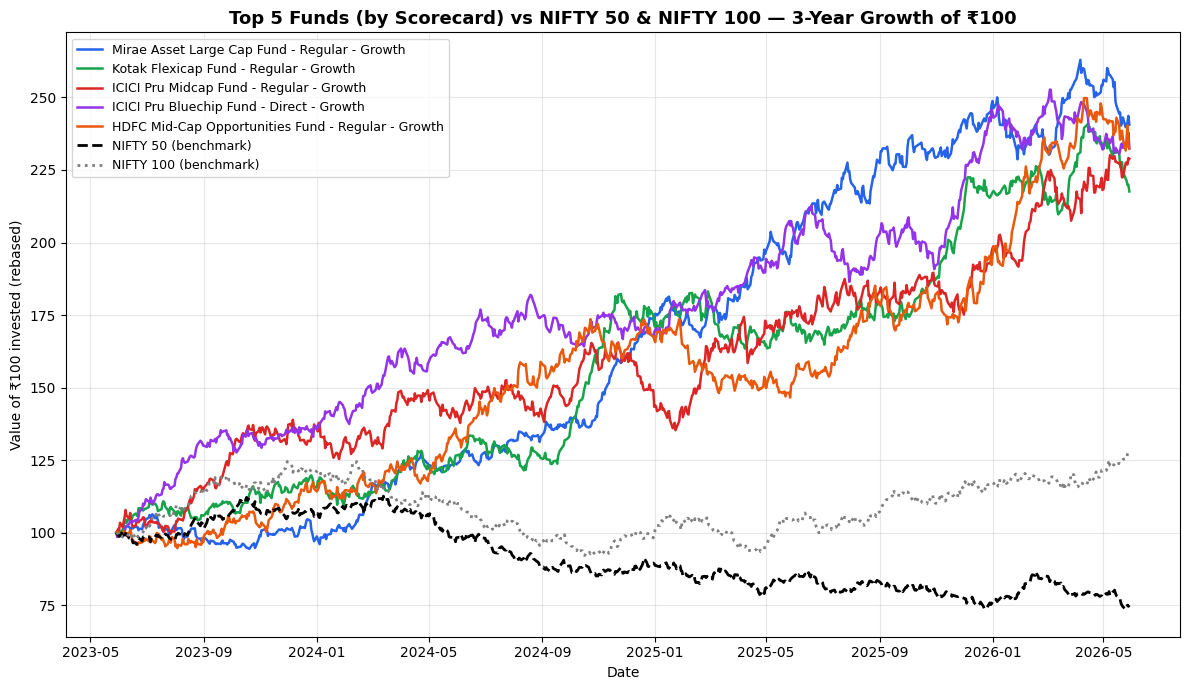

In [12]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

top5_codes = sc.head(5).index.tolist()
top5_names = sc.head(5)['scheme_name'].to_dict()

start_3y = nav_wide.index[nav_wide.index >= (end_date - pd.DateOffset(years=3))][0]
nav_window = nav_wide.loc[start_3y:end_date, top5_codes]
bm_window = bm_wide.loc[start_3y:end_date, ['NIFTY50','NIFTY100']]
nav_rebased = nav_window / nav_window.iloc[0] * 100
bm_rebased = bm_window / bm_window.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12,7))
colors = ['#2563eb','#16a34a','#dc2626','#9333ea','#ea580c']
for i, c in enumerate(top5_codes):
    ax.plot(nav_rebased.index, nav_rebased[c], label=top5_names[c], color=colors[i], linewidth=1.8)
ax.plot(bm_rebased.index, bm_rebased['NIFTY50'], label='NIFTY 50 (benchmark)', color='black', linewidth=2, linestyle='--')
ax.plot(bm_rebased.index, bm_rebased['NIFTY100'], label='NIFTY 100 (benchmark)', color='gray', linewidth=2, linestyle=':')
ax.set_title('Top 5 Funds (by Scorecard) vs NIFTY 50 & NIFTY 100 — 3-Year Growth of \u20b9100', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Value of \u20b9100 invested (rebased)')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('benchmark_comparison_top5.png', dpi=150)
plt.show()
print("Chart saved: benchmark_comparison_top5.png")

In [13]:
te_rows = []
for c in top5_codes:
    bench_code = fm.loc[c, 'benchmark_code']
    fund_r = daily_returns.loc[start_3y:end_date, c]
    bench_r = bm_returns.loc[start_3y:end_date, bench_code]
    aligned = pd.concat([fund_r, bench_r], axis=1, keys=['fund','bench']).dropna()
    te = (aligned['fund'] - aligned['bench']).std() * np.sqrt(252)
    te_rows.append({'amfi_code': c, 'scheme_name': fm.loc[c,'scheme_name'],
                     'benchmark': fm.loc[c,'benchmark'], 'Tracking_Error_3Y': te})

te_table = pd.DataFrame(te_rows).set_index('amfi_code')
print("Tracking Error (3Y, annualized) — Top 5 funds vs own assigned benchmark:")
print(te_table.round(4).to_string())
te_table.round(4).to_csv('tracking_error_top5.csv')

Tracking Error (3Y, annualized) — Top 5 funds vs own assigned benchmark:
                                                  scheme_name             benchmark  Tracking_Error_3Y
amfi_code                                                                                             
148567          Mirae Asset Large Cap Fund - Regular - Growth         NIFTY 100 TRI             0.1879
120843                 Kotak Flexicap Fund - Regular - Growth         NIFTY 500 TRI             0.2104
120505               ICICI Pru Midcap Fund - Regular - Growth  NIFTY Midcap 150 TRI             0.2615
120504              ICICI Pru Bluechip Fund - Direct - Growth         NIFTY 100 TRI             0.1873
100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth  NIFTY Midcap 150 TRI             0.2501


## 10. Summary
- **Deliverables produced:** `fund_scorecard.csv`, `alpha_beta.csv`, `tracking_error_top5.csv`, `benchmark_comparison_top5.png`, plus this notebook.
- **Top fund overall:** Mirae Asset Large Cap Fund (Scorecard 86.75) — strongest blend of 3Y return, Sharpe, and Alpha.
- **Safest funds (lowest drawdown):** the 3 liquid funds (ICICI Pru, Kotak, ABSL) — under 0.2% max drawdown, as expected for debt/liquid category.
- **Riskiest:** small-cap equity funds show drawdowns of 29–53%, consistent with their risk category label of *Very High*.
- **Data caveat:** 5Y CAGR is not computable (only 4.40 years of history provided). 3 of 10 stated benchmarks had no exact matching index series and were proxied to the closest available one (see Section 1).